In [1]:
# Customer Segmentation using K-Means Clustering
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the Dataset
# Read the customer dataset
df = pd.read_csv("Mall_Customers.csv")

In [3]:
# Display first 5 rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Check dataset structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
# Generate statistical summary
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


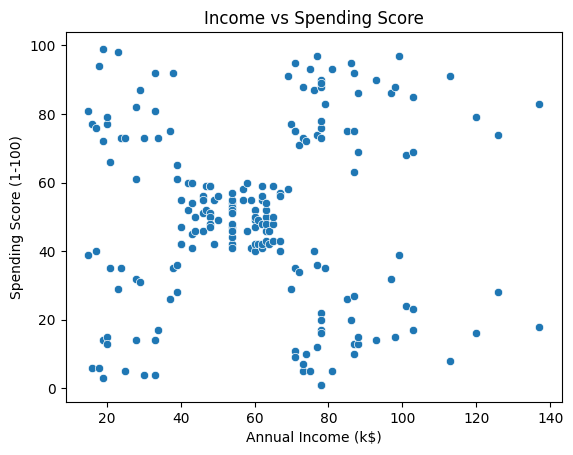

In [6]:
# Data Visualization
# Scatter Plot
# Visualize annual income vs spending score
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Income vs Spending Score")
plt.show()

In [7]:
# Feature Selection
# Select important features for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [8]:
# Feature Scaling
# Standardize feature values for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Apply K-Means Clustering
# Create K-Means model with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)

In [10]:
# Predict cluster labels
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [11]:
# Display Clustered Dataset
# View dataset with cluster labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


In [12]:
# 3D Customer Segmentation Visualization
# Create interactive 3D scatter plot
fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Cluster',
    title='3D Customer Segmentation'
)

fig.show(renderer='browser')

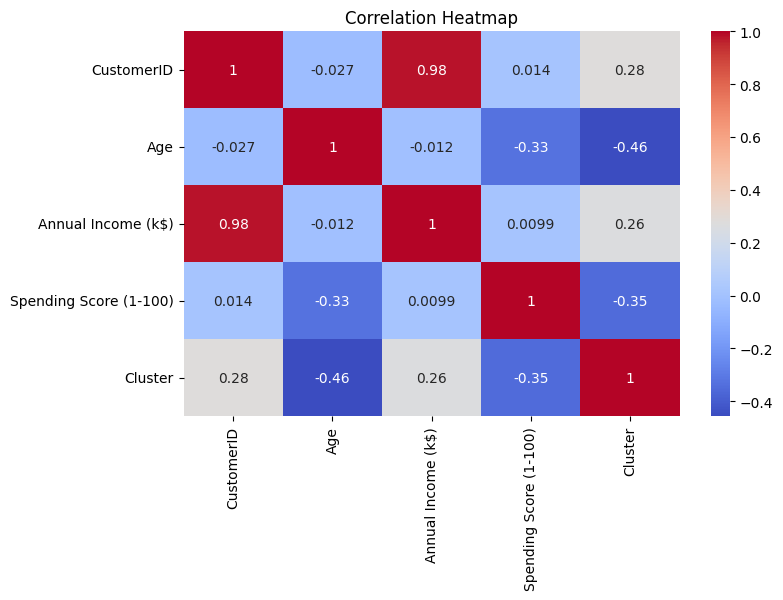

In [13]:
# Correlation Heatmap
# Display correlation matrix
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()